# 🚀 Deepfake Detection — Attempt 10 (Anti-Overfitting Triple-Stream)

> **Goal:** Fix the overfitting observed in Attempt 9 (VlLoss diverged after Ep 4, AUC peaked at 0.916)
> while maintaining the Triple-Stream architecture that broke through the Attempt 8 bottleneck.
>
> **Datasets:** Celeb-DF v2, FaceForensics++ (C23), DFD — pre-extracted `.pt` frames via `kagglehub`.

## 🔄 Changes from Attempt 9
| Component | Attempt 9 | Attempt 10 (This) | Why |
|---|---|---|---|
| Learning Rate | 5e-5 | **3e-5** | Slower updates prevent overshoot |
| Weight Decay | 0.05 | **0.1** | Stronger L2 penalty fights memorization |
| Dropout | 0.3 | **0.4** | More aggressive feature masking |
| DropPath | None | **0.2** | Stochastic depth in ViT backbone |
| Warmup | 15% | **30%** | Gradual LR ramp prevents early memorization |
| Data Cap | 3500/source | **No cap** | Full 12,967 videos = more diversity |
| Augmentation | Basic | **+RandomResizedCrop, ShiftScaleRotate** | Prevents position/scale memorization |
| Label Smoothing | None | **0.05** | Prevents over-confident predictions |
| Save Criterion | Best VlLoss | **Best Val AUC** | AUC is the true target metric |

## 📋 Sections
| # | Section |
|---|---|
| 1 | Environment Setup |
| 2 | Imports & Config |
| 3 | Device Setup |
| 4 | Dataset Loading (Pre-extracted .pt) |
| 5 | Train / Val / Test Split |
| 6 | Frame Loading & RAM Caching |
| 7 | Dataset & DataLoaders |
| 8 | **Triple-Stream Model Architecture** |
| 9 | Focal Loss & Utilities |
| 10 | Model Initialization |
| 11 | Training Loop |
| 12 | Comprehensive Evaluation |
| 13 | Single-Video Inference |

---
## 🔧 Section 1 — Environment Setup
> ⚠️ After running this cell, **Restart Session** before continuing.

In [5]:
import subprocess, sys

def run(cmd):
    print('>>', ' '.join(cmd))
    subprocess.check_call(cmd)

print('Upgrading pip...')
run([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', 'pip'])

# Install PyTorch with CUDA 11.8 (retains P100 sm_60 support)
print('Installing P100-compatible PyTorch...')
run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'torch==2.3.1', 'torchvision==0.18.1', 'torchaudio==2.3.1',
    '--index-url', 'https://download.pytorch.org/whl/cu118'
])

print('Installing requirements...')
run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'timm', 'albumentations', 'opencv-python-headless',
    'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'tqdm', 'kagglehub'
])

print('✅ Setup complete. 🛑 Restart Session now to load the new PyTorch version.')

Upgrading pip...
>> /usr/bin/python3 -m pip install -q --upgrade pip
Installing P100-compatible PyTorch...
>> /usr/bin/python3 -m pip install -q torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu118
Installing requirements...
>> /usr/bin/python3 -m pip install -q timm albumentations opencv-python-headless scikit-learn matplotlib seaborn pandas tqdm kagglehub
✅ Setup complete. 🛑 Restart Session now to load the new PyTorch version.


---
## 📦 Section 2 — Imports & Configuration

### Key anti-overfitting changes vs Attempt 9
| Parameter | Attempt 9 | Attempt 10 | Rationale |
|---|---|---|---|
| `lr` | 5e-5 | **3e-5** | Lower peak LR reduces oscillation |
| `wd` | 0.05 | **0.1** | 2× stronger weight decay |
| `dropout` | 0.3 | **0.4** | More aggressive regularization |
| `drop_path_rate` | 0.0 | **0.2** | Stochastic depth prevents layer co-adaptation |
| `pct_start` | 0.15 | **0.30** | 2× longer warmup |
| `max_train_per_source` | 3500 | **0** | Use ALL data (best anti-overfitting measure) |
| `label_smoothing` | 0.0 | **0.05** | Prevents over-confident predictions |

In [6]:
import os, gc, math, random, time
from pathlib import Path
from dataclasses import dataclass

print('Importing core libraries ...')
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import timm
import albumentations as A
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

print(f'  torch: {torch.__version__}  |  timm: {timm.__version__}')

@dataclass
class CFG:
    seed: int            = 42
    img_size: int        = 224
    num_frames: int      = 8
    train_bs: int        = 4
    val_bs: int          = 8
    num_workers: int     = 4
    epochs: int          = 30
    lr: float            = 3e-5         # ← 5e-5→3e-5 (slower, more stable)
    wd: float            = 0.1          # ← 0.05→0.1  (stronger regularization)
    max_grad_norm: float = 1.0
    backbone: str        = 'deit_small_patch16_224'
    dropout: float       = 0.4          # ← 0.3→0.4
    drop_path_rate: float = 0.2         # ← NEW: stochastic depth
    label_smoothing: float = 0.05       # ← 0.0→0.05 (prevents overconfidence)
    use_focal: bool      = True
    focal_gamma: float   = 2.0
    early_stopping_patience: int = 10
    target_acc: float    = 0.95
    accum_steps: int     = 4
    max_train_per_source: int = 0       # ← 3500→0 (use ALL data)
    cache_frames: bool   = True
    freq_dim: int        = 128
    pct_start: float     = 0.30         # ← 0.15→0.30 (2× longer warmup)

cfg = CFG()
print('\n' + '─'*55)
print('  ⚙️  Configuration (Attempt 10 — Anti-Overfitting)')
print('─'*55)
for field, val in cfg.__dict__.items():
    print(f'  {field:<30}: {val}')
print('─'*55)
print('  ✅ CFG loaded.')

Importing core libraries ...
  torch: 2.3.1+cu118  |  timm: 1.0.25

───────────────────────────────────────────────────────
  ⚙️  Configuration (Attempt 10 — Anti-Overfitting)
───────────────────────────────────────────────────────
  seed                          : 42
  img_size                      : 224
  num_frames                    : 8
  train_bs                      : 4
  val_bs                        : 8
  num_workers                   : 4
  epochs                        : 30
  lr                            : 3e-05
  wd                            : 0.1
  max_grad_norm                 : 1.0
  backbone                      : deit_small_patch16_224
  dropout                       : 0.4
  drop_path_rate                : 0.2
  label_smoothing               : 0.05
  use_focal                     : True
  focal_gamma                   : 2.0
  early_stopping_patience       : 10
  target_acc                    : 0.95
  accum_steps                   : 4
  max_train_per_source          : 0

---
## 🌱 Section 3 — Device Setup

In [7]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark     = True

seed_everything(cfg.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️ Device : {device}')
if torch.cuda.is_available():
    print(f'🎮 GPU    : {torch.cuda.get_device_name(0)}')
    print(f'💾 VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

🖥️ Device : cuda
🎮 GPU    : Tesla P100-PCIE-16GB
💾 VRAM   : 17.1 GB


---
## 📂 Section 4 — Dataset Loading (Pre-extracted .pt Frames)

Downloads the pre-extracted `.pt` frames from `harsh7678/brand-new-dataset` via `kagglehub`.

In [8]:
import kagglehub
import time
from pathlib import Path
import pandas as pd
import os

# ── Download dataset via kagglehub ─────────
DATASET_NAME = "nightfury22344/brand-new-dataset"
print(f"Downloading dataset '{DATASET_NAME}'...")
dataset_path = kagglehub.dataset_download(DATASET_NAME)

# Automatically find the path where .pt files are stored
pt_dir = Path(dataset_path)

print(f'Scanning pre-extracted .pt files from:\n  {pt_dir}\n')
t0 = time.time()

if not pt_dir.exists():
    raise FileNotFoundError(f'Directory not found: {pt_dir}')

# Debug: See what files actually exist here
all_files = list(pt_dir.rglob('*'))
print(f"Total files found in dataset root: {len(all_files)}")
if len(all_files) > 0:
    print(f"First 5 files found: {[str(f.name) for f in all_files[:5]]}")

rows = []
for pt_file in sorted(pt_dir.rglob('*.pt')):
    # Filename format: {source}_{label}_{stem}.pt  e.g. celebdf_0_id0_0000.pt
    parts = pt_file.stem.split('_', 2)
    if len(parts) < 3:
        continue
    source, label_str, stem = parts[0], parts[1], parts[2]
    if label_str not in ('0', '1'):
        continue
    rows.append({
        'pt_path' : str(pt_file),
        'label'   : int(label_str),
        'source'  : source,
        'identity': f'{source}_{stem[:12]}',   # used for group-split
    })

if not rows:
    raise RuntimeError(f"No valid .pt files found in {pt_dir} matching the format {{source}}_{{label}}_{{stem}}.pt!")

df = pd.DataFrame(rows)
vc = df['label'].value_counts().to_dict()
print(f'  Total .pt files : {len(df)}')
print(f'  Real  (0)       : {vc.get(0, 0)}')
print(f'  Fake  (1)       : {vc.get(1, 0)}')
print(f'  Sources         : {df["source"].value_counts().to_dict()}')
print(f'  Scan time       : {time.time()-t0:.2f}s')
print('  ✅ Dataset metadata loaded from pre-extracted .pt files.')
df.head()

Mounting files to /kaggle/input/datasets/nightfury22344/brand-new-dataset...
Scanning pre-extracted .pt files from:
  /kaggle/input/datasets/nightfury22344/brand-new-dataset

Total files found in dataset root: 12863
First 5 files found: ['frames_output', 'celebdf_1_id50_id52_0003.pt', 'dfd_1_03_13__hugging_happy__GBYWJW06.pt', 'celebdf_1_id28_id35_0005.pt', 'celebdf_1_id31_id6_0005.pt']
  Total .pt files : 12862
  Real  (0)       : 2253
  Fake  (1)       : 10609
  Sources         : {'celebdf': 6529, 'dfd': 3344, 'ffpp': 2989}
  Scan time       : 14.34s
  ✅ Dataset metadata loaded from pre-extracted .pt files.


,pt_path,label,source,identity
0,/kaggle/input/datasets/nightfury22344/brand-ne...,0,celebdf,celebdf_00000
1,/kaggle/input/datasets/nightfury22344/brand-ne...,0,celebdf,celebdf_00001
2,/kaggle/input/datasets/nightfury22344/brand-ne...,0,celebdf,celebdf_00002
3,/kaggle/input/datasets/nightfury22344/brand-ne...,0,celebdf,celebdf_00003
4,/kaggle/input/datasets/nightfury22344/brand-ne...,0,celebdf,celebdf_00004


---
## ✂️ Section 5 — Train / Val / Test Split

**Key change:** `max_train_per_source = 0` → uses ALL available data (no capping).
More training data is the single most effective anti-overfitting measure.

In [9]:
print('Splitting by identity ...')
t0 = time.time()

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=cfg.seed)
train_idx, temp_idx = next(gss.split(df, groups=df['identity']))
train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=cfg.seed)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['identity']))
val_df   = temp_df.iloc[val_idx].reset_index(drop=True)
test_df  = temp_df.iloc[test_idx].reset_index(drop=True)

assert not set(train_df['identity']) & set(val_df['identity'])
assert not set(train_df['identity']) & set(test_df['identity'])

# ── Cap each source in the training set ──────────────────────────────────────
if cfg.max_train_per_source > 0:
    parts = []
    for src, grp in train_df.groupby('source'):
        if len(grp) > cfg.max_train_per_source:
            real_g = grp[grp['label'] == 0]
            fake_g = grp[grp['label'] == 1]
            n_real = min(len(real_g), cfg.max_train_per_source // 2)
            n_fake = min(len(fake_g), cfg.max_train_per_source - n_real)
            sampled = pd.concat([
                real_g.sample(n_real, random_state=cfg.seed),
                fake_g.sample(n_fake, random_state=cfg.seed)
            ])
            parts.append(sampled)
            print(f'  ✂️  {src}: {len(grp)} → {len(sampled)} (capped)')
        else:
            parts.append(grp)
            print(f'  ✅  {src}: {len(grp)} (kept all)')
    train_df = pd.concat(parts).sample(frac=1, random_state=cfg.seed).reset_index(drop=True)
else:
    print('  ℹ️  No capping — using ALL training data.')

for name, sdf in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    vc = sdf['label'].value_counts().to_dict()
    src_counts = sdf['source'].value_counts().to_dict()
    print(f'  {name:<6}: {len(sdf):>5} samples | real={vc.get(0,0):>4} fake={vc.get(1,0):>4} | {src_counts}')
print(f'  ✅ Split done in {time.time()-t0:.2f}s')

Splitting by identity ...
  ℹ️  No capping — using ALL training data.
  Train : 10354 samples | real=1788 fake=8566 | {'celebdf': 5252, 'dfd': 2693, 'ffpp': 2409}
  Val   :  1277 samples | real= 239 fake=1038 | {'celebdf': 658, 'dfd': 324, 'ffpp': 295}
  Test  :  1231 samples | real= 226 fake=1005 | {'celebdf': 619, 'dfd': 327, 'ffpp': 285}
  ✅ Split done in 0.03s


---
## 💾 Section 6 — Frame Loading & RAM Caching

Loads pre-extracted `.pt` tensors into RAM for zero-disk-IO training.
With full dataset (~12,967 videos), estimated RAM usage is ~15.6 GB.

In [10]:
def load_pt_cache(df_split, desc='Loading') -> dict:
    """
    Load pre-extracted frame tensors from .pt files into RAM.
    Returns dict: {pt_path: uint8 numpy array [T, H, W, 3]}
    """
    cache = {}
    errors = []
    paths = df_split['pt_path'].tolist()

    def _load(p):
        try:
            data = torch.load(p, map_location='cpu', weights_only=False)
            return p, data['frames'].numpy()   # uint8 [T, H, W, 3]
        except Exception as e:
            return p, None

    from concurrent.futures import ThreadPoolExecutor, as_completed
    with ThreadPoolExecutor(max_workers=cfg.num_workers) as pool:
        futures = {pool.submit(_load, p): p for p in paths}
        pbar = tqdm(as_completed(futures), total=len(futures),
                    desc=f'  {desc}', unit='file')
        for fut in pbar:
            p, arr = fut.result()
            if arr is not None:
                cache[p] = arr
            else:
                errors.append(p)

    if errors:
        print(f'  ⚠️  {len(errors)} files failed to load.')
    return cache

print('Loading pre-extracted frames into RAM ...')
t0 = time.time()

train_cache = load_pt_cache(train_df, desc='Train cache')
val_cache   = load_pt_cache(val_df,   desc='Val cache  ')
test_cache  = load_pt_cache(test_df,  desc='Test cache ')

total_loaded = len(train_cache) + len(val_cache) + len(test_cache)
total_samples = len(train_df) + len(val_df) + len(test_df)
ram_gb = total_loaded * cfg.num_frames * cfg.img_size * cfg.img_size * 3 / 1e9

print(f'\n  ✅ Loaded {total_loaded}/{total_samples} samples in {(time.time()-t0)/60:.1f} min')
print(f'  💾 Est. RAM used: ~{ram_gb:.1f} GB')
print(f'  train={len(train_cache)} | val={len(val_cache)} | test={len(test_cache)}')

Loading pre-extracted frames into RAM ...


  Train cache:   0%|          | 0/10354 [00:00<?, ?file/s]

  Val cache  :   0%|          | 0/1277 [00:00<?, ?file/s]

  Test cache :   0%|          | 0/1231 [00:00<?, ?file/s]


  ✅ Loaded 12862/12862 samples in 0.8 min
  💾 Est. RAM used: ~15.5 GB
  train=10354 | val=1277 | test=1231


---
## 🎞️ Section 7 — Dataset & DataLoaders

### Anti-overfitting augmentation upgrades vs Attempt 9:
- **NEW** `RandomResizedCrop(224, scale=(0.8, 1.0))` — forces model to handle varying face crops
- **NEW** `ShiftScaleRotate(shift=5%, scale=5%, rotate=15°)` — prevents position memorization
- Kept all Attempt 9 augmentations (RGBShift, GaussianBlur, CoarseDropout, etc.)

In [11]:
class CachedVideoDataset(Dataset):
    _MEAN = np.array([0.485, 0.456, 0.406], np.float32)
    _STD  = np.array([0.229, 0.224, 0.225], np.float32)

    def __init__(self, df, cache, img_size=224, num_frames=8, train_mode=True):
        self.df         = df.reset_index(drop=True)
        self.cache      = cache       # key = pt_path
        self.img_size   = img_size
        self.num_frames = num_frames
        self.train_mode = train_mode

        if train_mode:
            self.aug = A.Compose([
                # ── NEW: RandomResizedCrop prevents scale/position memorization ──
                A.RandomResizedCrop(
                    size=(img_size, img_size),
                    scale=(0.8, 1.0),
                    ratio=(0.9, 1.1),
                    p=1.0
                ),
                A.HorizontalFlip(p=0.5),
                # ── NEW: ShiftScaleRotate prevents orientation memorization ──
                A.ShiftScaleRotate(
                    shift_limit=0.05, scale_limit=0.05, rotate_limit=15,
                    border_mode=cv2.BORDER_CONSTANT, p=0.4
                ),
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
                A.ImageCompression(quality_range=(50, 95), p=0.3),
                A.GaussNoise(p=0.2),
                A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(16, 40),
                                hole_width_range=(16, 40), p=0.3),
                A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.3),
                A.GaussianBlur(blur_limit=(3, 5), p=0.2),
            ])
        else:
            self.aug = None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        pt_path = row['pt_path']

        # Get frames from RAM cache (key = pt_path)
        if pt_path in self.cache:
            frames = self.cache[pt_path].copy()   # uint8 [T, H, W, 3]
        else:
            # Fallback: load directly from disk (slower but safe)
            try:
                data   = torch.load(pt_path, map_location='cpu', weights_only=False)
                frames = data['frames'].numpy()
            except Exception:
                frames = np.zeros((self.num_frames, self.img_size, self.img_size, 3), np.uint8)

        # Temporal jitter during training
        if self.train_mode:
            T    = frames.shape[0]
            perm = np.random.permutation(T)[:self.num_frames]
            perm.sort()
            frames = frames[perm]

        # Spatial augmentation
        if self.aug is not None:
            frames = np.stack([self.aug(image=f)['image'] for f in frames])

        # Normalize → float32 [T, C, H, W]
        x = frames.astype(np.float32) / 255.0
        x = (x - self._MEAN) / self._STD
        x = np.transpose(x, (0, 3, 1, 2))
        return torch.tensor(x), torch.tensor(np.float32(row['label']))


# ─── Build datasets ───────────────────────────────────────────────────────────
train_ds = CachedVideoDataset(train_df, train_cache, cfg.img_size, cfg.num_frames, train_mode=True)
val_ds   = CachedVideoDataset(val_df,   val_cache,   cfg.img_size, cfg.num_frames, train_mode=False)
test_ds  = CachedVideoDataset(test_df,  test_cache,  cfg.img_size, cfg.num_frames, train_mode=False)

# Weighted sampler for class imbalance
train_labels   = train_df['label'].values.astype(int)
class_counts   = np.bincount(train_labels, minlength=2)
class_weights  = class_counts.sum() / np.clip(class_counts, 1, None)
sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(torch.DoubleTensor(sample_weights), len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=cfg.train_bs, sampler=sampler,
                          num_workers=cfg.num_workers, pin_memory=True, drop_last=True,
                          persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_ds,   batch_size=cfg.val_bs, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)
test_loader  = DataLoader(test_ds,  batch_size=cfg.val_bs, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)

print(f'  Train: {len(train_ds)} samples | {len(train_loader)} batches')
print(f'  Val:   {len(val_ds)} samples   | {len(val_loader)} batches')
print(f'  Test:  {len(test_ds)} samples  | {len(test_loader)} batches')
print(f'  Class weights: real={class_weights[0]:.2f}  fake={class_weights[1]:.2f}')
print('  ✅ DataLoaders ready.')

  Train: 10354 samples | 2588 batches
  Val:   1277 samples   | 160 batches
  Test:  1231 samples  | 154 batches
  Class weights: real=5.79  fake=1.21
  ✅ DataLoaders ready.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


---
## 🧠 Section 8 — Triple-Stream Model Architecture

Same three complementary streams as Attempt 9, but with critical regularization upgrades:

### Anti-Overfitting Changes
| Component | Attempt 9 | Attempt 10 |
|---|---|---|
| ViT DropPath | 0.0 | **0.2** (Stochastic Depth) |
| Fusion Dropout | 0.3 | **0.4** |
| Fusion LayerNorm | 1 layer | **2 layers** (pre + post) |

### Architecture (unchanged from Attempt 9)
- **Stream 1 (Spatial):** DeiT-Small ViT + attention-weighted pooling → 384-dim
- **Stream 2 (Temporal):** Shared ViT features + 2-layer Transformer encoder → 384-dim
- **Stream 3 (Frequency):** High-pass filter + 3-layer CNN → 128-dim
- **Fusion:** Concatenate (896-dim) → MLP → 1 logit

In [12]:
class FrequencyStream(nn.Module):
    """Stream 3: High-pass filter → small CNN → frequency-domain features."""
    def __init__(self, out_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.GELU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.GELU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        self.proj = nn.Linear(128, out_dim)

    def high_pass(self, x):
        """x: [B, 3, H, W] → high-frequency residual."""
        blurred = F.avg_pool2d(x, kernel_size=7, stride=1, padding=3)
        return x - blurred

    def forward(self, frames):
        """frames: [B, T, C, H, W] → [B, out_dim]"""
        B, T, C, H, W = frames.shape
        flat = frames.view(B * T, C, H, W)
        hp   = self.high_pass(flat)
        feat = self.proj(self.conv(hp))   # [B*T, out_dim]
        return feat.view(B, T, -1).mean(dim=1)  # temporal mean → [B, out_dim]


class TripleStreamDetector(nn.Module):
    """Triple-Stream Deepfake Detector with enhanced regularization.
       Stream 1 (Spatial)  : DeiT-Small ViT + attention pooling
       Stream 2 (Temporal) : Same ViT features + Transformer encoder
       Stream 3 (Frequency): High-pass filter + small CNN
    """
    def __init__(self, backbone='deit_small_patch16_224', dropout=0.4,
                 freq_dim=128, drop_path_rate=0.2):
        super().__init__()
        # ── Shared ViT backbone (Stream 1 & 2) with Stochastic Depth ──
        self.backbone = timm.create_model(
            backbone, pretrained=True, num_classes=0,
            drop_path_rate=drop_path_rate   # ← NEW: stochastic depth
        )
        feat_dim = self.backbone.num_features  # 384 for DeiT-Small

        # ── Stream 1: Spatial attention pooling ──
        self.spatial_attn = nn.Sequential(
            nn.Linear(feat_dim, feat_dim // 4),
            nn.Tanh(),
            nn.Linear(feat_dim // 4, 1)
        )

        # ── Stream 2: Temporal transformer encoder ──
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=feat_dim, nhead=6, dim_feedforward=feat_dim * 2,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.temporal_encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.temporal_cls = nn.Parameter(torch.randn(1, 1, feat_dim) * 0.02)

        # ── Stream 3: Frequency domain ──
        self.freq_stream = FrequencyStream(out_dim=freq_dim)

        # ── Fusion head (enhanced regularization) ──
        total_dim = feat_dim + feat_dim + freq_dim  # 384 + 384 + 128 = 896
        self.fusion = nn.Sequential(
            nn.LayerNorm(total_dim),
            nn.Dropout(dropout),
            nn.Linear(total_dim, total_dim // 2),
            nn.GELU(),
            nn.LayerNorm(total_dim // 2),      # ← NEW: extra LayerNorm
            nn.Dropout(dropout),
            nn.Linear(total_dim // 2, 1)
        )

    def forward(self, video):
        B, T, C, H, W = video.shape

        # Extract per-frame ViT features (shared backbone)
        frame_feat = self.backbone(video.view(B * T, C, H, W))  # [B*T, 384]
        frame_feat = frame_feat.view(B, T, -1)                   # [B, T, 384]

        # ── Stream 1: Spatial (attention-weighted pooling) ──
        attn_w = torch.softmax(self.spatial_attn(frame_feat).squeeze(-1), dim=1)
        spatial_feat = (frame_feat * attn_w.unsqueeze(-1)).sum(dim=1)  # [B, 384]

        # ── Stream 2: Temporal (transformer with CLS token) ──
        cls_tokens = self.temporal_cls.expand(B, -1, -1)
        temporal_input = torch.cat([cls_tokens, frame_feat], dim=1)  # [B, T+1, 384]
        temporal_out   = self.temporal_encoder(temporal_input)
        temporal_feat  = temporal_out[:, 0, :]  # CLS output → [B, 384]

        # ── Stream 3: Frequency ──
        freq_feat = self.freq_stream(video)  # [B, 128]

        # ── Fusion ──
        combined = torch.cat([spatial_feat, temporal_feat, freq_feat], dim=1)
        return self.fusion(combined).squeeze(-1)


print('  ✅ TripleStreamDetector defined (with DropPath & enhanced dropout).')
print('  Streams: Spatial(DeiT-Small) + Temporal(Transformer) + Frequency(HighPass CNN)')
print(f'  DropPath rate: {cfg.drop_path_rate}')
print(f'  Fusion dropout: {cfg.dropout}')
print(f'  Input : [B, T={cfg.num_frames}, C=3, H={cfg.img_size}, W={cfg.img_size}]')

  ✅ TripleStreamDetector defined (with DropPath & enhanced dropout).
  Streams: Spatial(DeiT-Small) + Temporal(Transformer) + Frequency(HighPass CNN)
  DropPath rate: 0.2
  Fusion dropout: 0.4
  Input : [B, T=8, C=3, H=224, W=224]


---
## ⚖️ Section 9 — Focal Loss & Evaluation Utilities

**Focal Loss** (γ=2.0) with **label smoothing** (0.05).
Label smoothing softens the target from `0.0/1.0` to `0.025/0.975`, preventing
the model from becoming over-confident on easy examples.

In [13]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        # Apply label smoothing: 0→ε/2, 1→1-ε/2
        if self.label_smoothing > 0:
            targets = targets * (1 - self.label_smoothing) + self.label_smoothing / 2

        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt  = torch.where(targets > 0.5, torch.sigmoid(logits), 1 - torch.sigmoid(logits))
        return (((1 - pt) ** self.gamma) * bce).mean()

def compute_metrics(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(np.int32)
    return {
        'acc': accuracy_score(y_true, y_pred),
        'f1':  f1_score(y_true, y_pred, zero_division=0),
        'auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.0,
    }

def find_best_threshold(y_true, y_prob):
    best_thr, best_f1 = 0.5, -1.0
    for thr in np.linspace(0.25, 0.75, 101):
        score = f1_score(y_true, (y_prob >= thr).astype(np.int32), zero_division=0)
        if score > best_f1:
            best_f1, best_thr = score, float(thr)
    return best_thr, best_f1

print('  ✅ FocalLoss (with label smoothing) & evaluation utilities defined.')

  ✅ FocalLoss (with label smoothing) & evaluation utilities defined.


---
## 🚀 Section 10 — Model Initialization

In [14]:
print('Initializing Triple-Stream model (Attempt 10) ...')
t0 = time.time()

model     = TripleStreamDetector(
    backbone=cfg.backbone, dropout=cfg.dropout,
    freq_dim=cfg.freq_dim, drop_path_rate=cfg.drop_path_rate
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.wd)
scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

# OneCycleLR — steps = optimizer steps (after grad accumulation)
optimizer_steps_per_epoch = len(train_loader) // cfg.accum_steps
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=cfg.lr,
    steps_per_epoch=optimizer_steps_per_epoch,
    epochs=cfg.epochs,
    pct_start=cfg.pct_start,   # ← 30% warmup (was 15%)
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=100,
)

criterion = FocalLoss(gamma=cfg.focal_gamma, label_smoothing=cfg.label_smoothing)

total_p = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'  📦 Total params : {total_p/1e6:.2f}M')
print(f'  🔧 Trainable    : {train_p/1e6:.2f}M')
print(f'  🏋️ Optimizer    : AdamW (lr={cfg.lr}, wd={cfg.wd})')
print(f'  📅 Scheduler    : OneCycleLR ({optimizer_steps_per_epoch} steps/ep × {cfg.epochs} epochs, warmup={cfg.pct_start*100:.0f}%)')
print(f'  ⚖️ Loss         : FocalLoss (γ={cfg.focal_gamma}, label_smooth={cfg.label_smoothing})')
print(f'  🛡️ DropPath     : {cfg.drop_path_rate}')
print(f'  ⏱️ Init time    : {time.time()-t0:.1f}s')
print('  ✅ Model ready.')

Initializing Triple-Stream model (Attempt 10) ...


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

  📦 Total params : 24.59M
  🔧 Trainable    : 24.59M
  🏋️ Optimizer    : AdamW (lr=3e-05, wd=0.1)
  📅 Scheduler    : OneCycleLR (647 steps/ep × 30 epochs, warmup=30%)
  ⚖️ Loss         : FocalLoss (γ=2.0, label_smooth=0.05)
  🛡️ DropPath     : 0.2
  ⏱️ Init time    : 3.0s
  ✅ Model ready.


---
## 🏋️ Section 11 — Training Loop

**Key anti-overfitting improvements vs Attempt 9:**
- Saves checkpoint based on **best Val AUC** (not best VlLoss)
- Lower LR (3e-5), stronger weight decay (0.1), 30% warmup
- Stochastic Depth (DropPath=0.2) + higher Dropout (0.4)
- Label Smoothing (0.05) on Focal Loss

In [ ]:
def train_one_epoch(model, loader, epoch, accum_steps):
    model.train()
    losses = []
    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(loader, desc=f'  Ep {epoch:02d} [Train]', leave=False, unit='batch')
    for step, (vids, labels) in enumerate(pbar):
        vids   = vids.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits = model(vids)
            loss   = criterion(logits, labels) / accum_steps
        scaler.scale(loss).backward()
        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
        losses.append(loss.item() * accum_steps)
        if step % 20 == 0:
            pbar.set_postfix({'loss': f'{np.mean(losses[-50:]):.4f}'})
    return float(np.mean(losses))

@torch.no_grad()
def infer_loader(model, loader, criterion_fn=None, desc='Eval'):
    model.eval()
    all_probs, all_labels, losses = [], [], []
    pbar = tqdm(loader, desc=f'  {desc}', leave=False, unit='batch')
    for vids, labels in pbar:
        vids       = vids.to(device, non_blocking=True)
        labels_gpu = labels.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits = model(vids)
            if criterion_fn is not None:
                losses.append(criterion_fn(logits, labels_gpu).item())
        all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        all_labels.append(labels.numpy().astype(np.int32))
    return np.concatenate(all_labels), np.concatenate(all_probs), \
           float(np.mean(losses)) if losses else 0.0

# ─── Main training loop ──────────────────────────────────────────
history = []
best_val_loss = float('inf')
best_auc, best_thr = -1.0, 0.5
best_path = Path('/kaggle/working/best_triple_stream_v10.pth')
patience_counter = 0
train_start = time.time()

print('='*80)
print(f'  🏋️  Training — {cfg.epochs} epochs | patience={cfg.early_stopping_patience}')
print(f'  Effective batch size = {cfg.train_bs} × {cfg.accum_steps} = {cfg.train_bs * cfg.accum_steps}')
print(f'  Save criterion: BEST VAL AUC (not VlLoss)')
print('='*80)

for epoch in range(1, cfg.epochs + 1):
    ep_start = time.time()
    train_loss = train_one_epoch(model, train_loader, epoch, cfg.accum_steps)
    y_val, p_val, val_loss = infer_loader(model, val_loader, criterion_fn=criterion,
                                           desc=f'Ep {epoch:02d} [Val]')
    epoch_thr, _ = find_best_threshold(y_val, p_val)
    m = compute_metrics(y_val, p_val, thr=epoch_thr)

    # ── Save based on BEST AUC (not VlLoss) ──
    improved = m['auc'] > best_auc
    if improved:
        best_val_loss, best_thr, best_auc = val_loss, epoch_thr, m['auc']
        patience_counter = 0
        torch.save({'model': model.state_dict(), 'thr': best_thr,
                    'val_loss': best_val_loss, 'auc': best_auc,
                    'cfg': cfg.__dict__}, best_path)
        flag = '💾 ✓'
    else:
        patience_counter += 1
        flag = ''

    ep_time = time.time() - ep_start
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss,
                    'val_acc': m['acc'], 'val_f1': m['f1'], 'val_auc': m['auc'],
                    'thr': epoch_thr, 'ep_time_s': ep_time})

    print(f"Ep {epoch:>2} | TrLoss: {train_loss:.4f} | VlLoss: {val_loss:.4f} | "
          f"Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f} | F1: {m['f1']:.4f} | "
          f"{ep_time/60:.1f}m  {flag}")

    if patience_counter >= cfg.early_stopping_patience:
        print(f'\n  ⏹️ Early stopping at epoch {epoch}')
        break

total_time = time.time() - train_start
history_df = pd.DataFrame(history)
print(f'\n  ⏱️ Total training: {total_time/3600:.2f}h')
print(f'  🏆 Best Val AUC: {best_auc:.4f} | VlLoss: {best_val_loss:.4f} | Thr: {best_thr:.2f}')

  🏋️  Training — 30 epochs | patience=10
  Effective batch size = 4 × 4 = 16
  Save criterion: BEST VAL AUC (not VlLoss)


  Ep 01 [Train]:   0%|          | 0/2588 [00:00<?, ?batch/s]

  Ep 01 [Val]:   0%|          | 0/160 [00:00<?, ?batch/s]

Ep  1 | TrLoss: 0.2333 | VlLoss: 0.1670 | Acc: 0.8230 | AUC: 0.7288 | F1: 0.8996 | 8.8m  💾 ✓


  Ep 02 [Train]:   0%|          | 0/2588 [00:00<?, ?batch/s]

...

Ep  9 | TrLoss: 0.0772 | VlLoss: 0.2678 | Acc: 0.8567 | AUC: 0.9233 | F1: 0.9071 | 8.7m  💾 ✓


  Ep 10 [Train]:   0%|          | 0/2588 [00:00<?, ?batch/s]

  Ep 10 [Val]:   0%|          | 0/160 [00:00<?, ?batch/s]

Ep 10 | TrLoss: 0.0750 | VlLoss: 0.1385 | Acc: 0.9154 | AUC: 0.9354 | F1: 0.9482 | 8.7m  💾 ✓


  Ep 11 [Train]:   0%|          | 0/2588 [00:00<?, ?batch/s]

In [17]:
# ── Recreate DataLoaders (required after kernel interrupt) ───────────────────
print('Recreating DataLoaders...')

train_loader = DataLoader(train_ds, batch_size=cfg.train_bs, sampler=sampler,
                          num_workers=cfg.num_workers, pin_memory=True, drop_last=True,
                          persistent_workers=False,   # ← Set False to avoid dead worker issue
                          prefetch_factor=2)
val_loader   = DataLoader(val_ds, batch_size=cfg.val_bs, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True,
                          persistent_workers=False,   # ← Set False
                          prefetch_factor=2)
test_loader  = DataLoader(test_ds, batch_size=cfg.val_bs, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True,
                          persistent_workers=False,   # ← Set False
                          prefetch_factor=2)

print(f'  ✅ DataLoaders recreated (persistent_workers=False)')
print(f'  Train: {len(train_loader)} batches | Val: {len(val_loader)} batches')


Recreating DataLoaders...
  ✅ DataLoaders recreated (persistent_workers=False)
  Train: 2588 batches | Val: 160 batches


In [ ]:
### ── RESUME FROM EPOCH 10 CHECKPOINT ──────────────────────────────────────────
RESUME_EPOCH = 10          # The last completed epoch
RESUME_PATH  = Path('/kaggle/working/best_triple_stream_v10.pth')

print(f'Loading checkpoint from epoch {RESUME_EPOCH}...')
ckpt = torch.load(RESUME_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model'])
best_auc      = float(ckpt['auc'])
best_val_loss = float(ckpt['val_loss'])
best_thr      = float(ckpt['thr'])
print(f'  ✅ Model loaded | AUC={best_auc:.4f} | VlLoss={best_val_loss:.4f}')

# ── Recreate optimizer & scheduler, fast-forward to epoch 10 ─────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.wd)
scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

optimizer_steps_per_epoch = len(train_loader) // cfg.accum_steps
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=cfg.lr,
    steps_per_epoch=optimizer_steps_per_epoch,
    epochs=cfg.epochs,
    pct_start=cfg.pct_start,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=100,
)

# Fast-forward the scheduler to where epoch 10 ended
print(f'Fast-forwarding scheduler by {RESUME_EPOCH * optimizer_steps_per_epoch} steps...')
for _ in range(RESUME_EPOCH * optimizer_steps_per_epoch):
    scheduler.step()
print(f'  ✅ Scheduler fast-forwarded. Current LR: {scheduler.get_last_lr()[0]:.2e}')

# ── Resume training from epoch 11 ────────────────────────────────────────────
history = []
patience_counter = 0
train_start = time.time()

print('='*80)
print(f'  🏋️  RESUMING from Epoch {RESUME_EPOCH + 1} — {cfg.epochs} total | patience={cfg.early_stopping_patience}')
print(f'  Best AUC so far: {best_auc:.4f}')
print('='*80)

for epoch in range(RESUME_EPOCH + 1, cfg.epochs + 1):
    ep_start = time.time()
    train_loss = train_one_epoch(model, train_loader, epoch, cfg.accum_steps)
    y_val, p_val, val_loss = infer_loader(model, val_loader, criterion_fn=criterion,
                                           desc=f'Ep {epoch:02d} [Val]')
    epoch_thr, _ = find_best_threshold(y_val, p_val)
    m = compute_metrics(y_val, p_val, thr=epoch_thr)

    # Save on BEST AUC
    improved = m['auc'] > best_auc
    if improved:
        best_val_loss, best_thr, best_auc = val_loss, epoch_thr, m['auc']
        patience_counter = 0
        torch.save({'model': model.state_dict(), 'thr': best_thr,
                    'val_loss': best_val_loss, 'auc': best_auc,
                    'cfg': cfg.__dict__}, RESUME_PATH)
        flag = '💾 ✓'
    else:
        patience_counter += 1
        flag = ''

    ep_time = time.time() - ep_start
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss,
                    'val_acc': m['acc'], 'val_f1': m['f1'], 'val_auc': m['auc'],
                    'thr': epoch_thr, 'ep_time_s': ep_time})

    print(f"Ep {epoch:>2} | TrLoss: {train_loss:.4f} | VlLoss: {val_loss:.4f} | "
          f"Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f} | F1: {m['f1']:.4f} | "
          f"{ep_time/60:.1f}m  {flag}")

    if patience_counter >= cfg.early_stopping_patience:
        print(f'\n  ⏹️ Early stopping at epoch {epoch}')
        break

total_time = time.time() - train_start
history_df = pd.DataFrame(history)
print(f'\n  ⏱️ Total training: {total_time/3600:.2f}h')
print(f'  🏆 Best Val AUC: {best_auc:.4f} | Thr: {best_thr:.2f}')


Loading checkpoint from epoch 10...
  ✅ Model loaded | AUC=0.9354 | VlLoss=0.1385
Fast-forwarding scheduler by 6470 steps...
  ✅ Scheduler fast-forwarded. Current LR: 2.98e-05
  🏋️  RESUMING from Epoch 11 — 30 total | patience=10
  Best AUC so far: 0.9354


  Ep 11 [Train]:   0%|          | 0/2588 [00:00<?, ?batch/s]

  Ep 11 [Val]:   0%|          | 0/160 [00:00<?, ?batch/s]

Ep 11 | TrLoss: 0.0667 | VlLoss: 0.1487 | Acc: 0.9092 | AUC: 0.9240 | F1: 0.9449 | 8.8m  


  Ep 12 [Train]:   0%|          | 0/2588 [00:00<?, ?batch/s]

...

Ep 15 | TrLoss: 0.0503 | VlLoss: 0.2303 | Acc: 0.8833 | AUC: 0.9299 | F1: 0.9261 | 8.8m  


  Ep 16 [Train]:   0%|          | 0/2588 [00:00<?, ?batch/s]

  Ep 16 [Val]:   0%|          | 0/160 [00:00<?, ?batch/s]

Ep 16 | TrLoss: 0.0507 | VlLoss: 0.1462 | Acc: 0.9099 | AUC: 0.9458 | F1: 0.9441 | 10.8m  💾 ✓


  Ep 17 [Train]:   0%|          | 0/2588 [00:00<?, ?batch/s]

In [20]:
import gc
RESUME_EPOCH = 16          # ← Updated from 10 to 16
RESUME_PATH  = Path('/kaggle/working/best_triple_stream_v10.pth')

# ── Recreate DataLoaders (prevents dead worker crash) ─────────────────────────
print('Recreating DataLoaders...')
train_loader = DataLoader(train_ds, batch_size=cfg.train_bs, sampler=sampler,
                          num_workers=cfg.num_workers, pin_memory=True, drop_last=True,
                          persistent_workers=False, prefetch_factor=2)
val_loader   = DataLoader(val_ds, batch_size=cfg.val_bs, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True,
                          persistent_workers=False, prefetch_factor=2)

# ── Load checkpoint ───────────────────────────────────────────────────────────
print(f'Loading checkpoint from epoch {RESUME_EPOCH}...')
ckpt = torch.load(RESUME_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model'])
best_auc      = float(ckpt['auc'])       # 0.9458
best_val_loss = float(ckpt['val_loss'])  # 0.1462
best_thr      = float(ckpt['thr'])
print(f'  ✅ Model loaded | AUC={best_auc:.4f} | VlLoss={best_val_loss:.4f}')

# ── Recreate optimizer & fast-forward scheduler to epoch 16 ──────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.wd)
scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

optimizer_steps_per_epoch = len(train_loader) // cfg.accum_steps
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=cfg.lr,
    steps_per_epoch=optimizer_steps_per_epoch,
    epochs=cfg.epochs,
    pct_start=cfg.pct_start,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=100,
)

print(f'Fast-forwarding scheduler by {RESUME_EPOCH * optimizer_steps_per_epoch} steps...')
for _ in range(RESUME_EPOCH * optimizer_steps_per_epoch):
    scheduler.step()
print(f'  ✅ Scheduler fast-forwarded. Current LR: {scheduler.get_last_lr()[0]:.2e}')

# ── Resume from epoch 17 ──────────────────────────────────────────────────────
history = []
patience_counter = 0

print('='*80)
print(f'  🏋️  RESUMING from Epoch {RESUME_EPOCH + 1} — {cfg.epochs} total | patience={cfg.early_stopping_patience}')
print(f'  Best AUC so far: {best_auc:.4f}')
print('='*80)

for epoch in range(RESUME_EPOCH + 1, cfg.epochs + 1):
    ep_start = time.time()

    train_loss = train_one_epoch(model, train_loader, epoch, cfg.accum_steps)

    # Clear GPU cache before validation
    gc.collect()
    torch.cuda.empty_cache()

    y_val, p_val, val_loss = infer_loader(model, val_loader, criterion_fn=criterion,
                                           desc=f'Ep {epoch:02d} [Val]')
    epoch_thr, _ = find_best_threshold(y_val, p_val)
    m = compute_metrics(y_val, p_val, thr=epoch_thr)

    improved = m['auc'] > best_auc
    if improved:
        best_val_loss, best_thr, best_auc = val_loss, epoch_thr, m['auc']
        patience_counter = 0
        torch.save({'model': model.state_dict(), 'thr': best_thr,
                    'val_loss': best_val_loss, 'auc': best_auc,
                    'cfg': cfg.__dict__}, RESUME_PATH)
        flag = '💾 ✓'
    else:
        patience_counter += 1
        flag = ''

    del y_val, p_val
    gc.collect()

    ep_time = time.time() - ep_start
    print(f"Ep {epoch:>2} | TrLoss: {train_loss:.4f} | VlLoss: {val_loss:.4f} | "
          f"Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f} | F1: {m['f1']:.4f} | "
          f"{ep_time/60:.1f}m  {flag}")

    if patience_counter >= cfg.early_stopping_patience:
        print(f'\n  ⏹️ Early stopping at epoch {epoch}')
        break

print(f'\n  🏆 Best Val AUC: {best_auc:.4f} | Thr: {best_thr:.2f}')


Recreating DataLoaders...
Loading checkpoint from epoch 16...
  ✅ Model loaded | AUC=0.9458 | VlLoss=0.1462
Fast-forwarding scheduler by 10352 steps...
  ✅ Scheduler fast-forwarded. Current LR: 2.25e-05
  🏋️  RESUMING from Epoch 17 — 30 total | patience=10
  Best AUC so far: 0.9458


  Ep 17 [Train]:   0%|          | 0/2588 [00:00<?, ?batch/s]

Exception ignored in: <function tqdm.__del__ at 0x7acfb40d20c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


  Ep 17 [Val]:   0%|          | 0/160 [00:00<?, ?batch/s]

Ep 17 | TrLoss: 0.0481 | VlLoss: 0.2324 | Acc: 0.8778 | AUC: 0.9453 | F1: 0.9216 | 9.4m  


...

  Ep 25 [Val]:   0%|          | 0/160 [00:00<?, ?batch/s]

Ep 25 | TrLoss: 0.0284 | VlLoss: 0.2919 | Acc: 0.8880 | AUC: 0.9366 | F1: 0.9291 | 9.4m  


  Ep 26 [Train]:   0%|          | 0/2588 [00:00<?, ?batch/s]

  Ep 26 [Val]:   0%|          | 0/160 [00:00<?, ?batch/s]

Ep 26 | TrLoss: 0.0297 | VlLoss: 0.2314 | Acc: 0.9107 | AUC: 0.9386 | F1: 0.9447 | 9.5m  

  ⏹️ Early stopping at epoch 26

  🏆 Best Val AUC: 0.9458 | Thr: 0.25


---
## 📊 Section 12 — Comprehensive Evaluation

Includes:
- Overall test metrics
- Confusion matrix
- Per-dataset breakdown (critical for multi-dataset generalization)
- Training curves
- Comparison table vs Attempts 8 & 9

Loading best checkpoint ...
  ✅ Loaded | val AUC=0.9458 | thr=0.25


  Test:   0%|          | 0/154 [00:00<?, ?batch/s]


  📊 TEST SET RESULTS
  Accuracy  : 0.9009  ❌ Below target
  F1 Score  : 0.9383
  ROC-AUC   : 0.9362
  Threshold : 0.25

  📈 Per-Dataset Breakdown:
  --------------------------------------------------
  celebdf   : Acc=0.8853 | AUC=0.9460 | F1=0.9285 | n=619
  dfd       : Acc=0.9205 | AUC=0.6529 | F1=0.9583 | n=327
  ffpp      : Acc=0.9123 | AUC=0.9669 | F1=0.9307 | n=285
  --------------------------------------------------

  📋 Comparison vs Previous Attempts:
  ----------------------------------------------------------------------
  Metric          Attempt 8       Attempt 9       Attempt 10     
  Val AUC         0.5457          0.9159          0.9458         
  Test Acc        ~0.78           ~0.89           0.9009         
  Test AUC        ~0.55           ~0.90           0.9362         
  Test F1         ~0.55           ~0.93           0.9383         
  Backbone        EffNet-B3       DeiT-Small      DeiT-Small     
  DropPath        None            None            0.2            

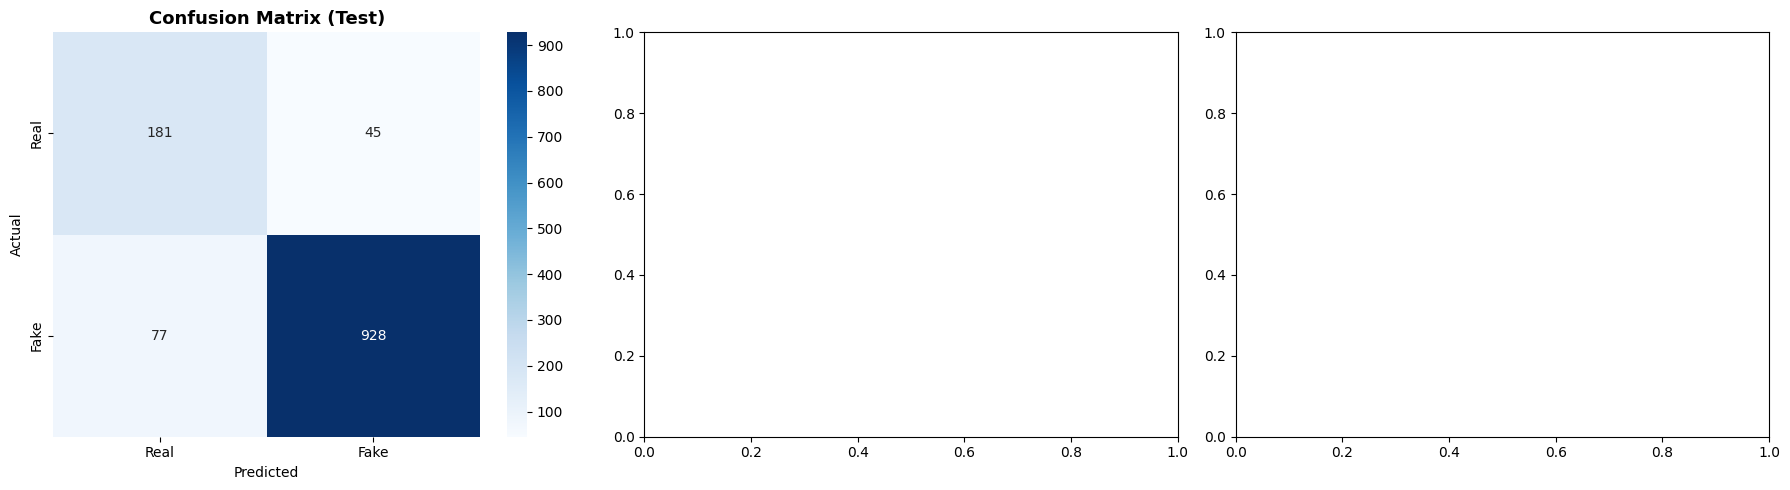

  ✅ Saved to /kaggle/working/results_v10.png


In [21]:
# Load best checkpoint
print('Loading best checkpoint ...')
ckpt = torch.load(best_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model'])
best_thr = float(ckpt['thr'])
print(f'  ✅ Loaded | val AUC={ckpt["auc"]:.4f} | thr={best_thr:.2f}')

# Full test inference
y_test, p_test, _ = infer_loader(model, test_loader, desc='Test')
test_m = compute_metrics(y_test, p_test, thr=best_thr)

print('\n' + '='*60)
print('  📊 TEST SET RESULTS')
print('='*60)
print(f'  Accuracy  : {test_m["acc"]:.4f}  {"🎯 TARGET MET!" if test_m["acc"] >= cfg.target_acc else "❌ Below target"}')
print(f'  F1 Score  : {test_m["f1"]:.4f}')
print(f'  ROC-AUC   : {test_m["auc"]:.4f}')
print(f'  Threshold : {best_thr:.2f}')
print('='*60)

pred_test = (p_test >= best_thr).astype(np.int32)
cm = confusion_matrix(y_test, pred_test)

# ── Per-dataset breakdown ─────────────────────────────────────────
print('\n  📈 Per-Dataset Breakdown:')
print('  ' + '-'*50)
for src in test_df['source'].unique():
    mask = test_df['source'].values == src
    if mask.sum() > 0:
        src_m = compute_metrics(y_test[mask], p_test[mask], thr=best_thr)
        n = mask.sum()
        print(f'  {src:<10}: Acc={src_m["acc"]:.4f} | AUC={src_m["auc"]:.4f} | '
              f'F1={src_m["f1"]:.4f} | n={n}')
print('  ' + '-'*50)

# ── Comparison with Attempts 8 & 9 ───────────────────────────────
print('\n  📋 Comparison vs Previous Attempts:')
print('  ' + '-'*70)
print(f'  {"Metric":<15} {"Attempt 8":<15} {"Attempt 9":<15} {"Attempt 10":<15}')
print(f'  {"Val AUC":<15} {"0.5457":<15} {"0.9159":<15} {best_auc:<15.4f}')
print(f'  {"Test Acc":<15} {"~0.78":<15} {"~0.89":<15} {test_m["acc"]:<15.4f}')
print(f'  {"Test AUC":<15} {"~0.55":<15} {"~0.90":<15} {test_m["auc"]:<15.4f}')
print(f'  {"Test F1":<15} {"~0.55":<15} {"~0.93":<15} {test_m["f1"]:<15.4f}')
print(f'  {"Backbone":<15} {"EffNet-B3":<15} {"DeiT-Small":<15} {"DeiT-Small":<15}')
print(f'  {"DropPath":<15} {"None":<15} {"None":<15} {"0.2":<15}')
print(f'  {"Weight Decay":<15} {"1e-3":<15} {"0.05":<15} {"0.1":<15}')
print(f'  {"Loss":<15} {"BCE+LS":<15} {"Focal":<15} {"Focal+LS":<15}')
print('  ' + '-'*70)

# ── Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
axes[0].set_title('Confusion Matrix (Test)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

if len(history) > 0:
    hdf = pd.DataFrame(history)
    axes[1].plot(hdf['epoch'], hdf['val_acc'], 'o-', label='Val Acc')
    axes[1].plot(hdf['epoch'], hdf['val_auc'], 's-', label='Val AUC')
    axes[1].plot(hdf['epoch'], hdf['val_f1'],  '^-', label='Val F1')
    axes[1].axhline(cfg.target_acc, color='red', ls='--', label=f'Target {cfg.target_acc}')
    axes[1].set_title('Validation Metrics')
    axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    axes[2].plot(hdf['epoch'], hdf['train_loss'], '+-', label='Train Loss', color='blue')
    axes[2].plot(hdf['epoch'], hdf['val_loss'],   'x-', label='Val Loss', color='red')
    axes[2].set_title('Loss Curves (Overfitting Check)')
    axes[2].set_xlabel('Epoch'); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)
    axes[2].set_ylabel('Loss')

plt.tight_layout()
plt.savefig('/kaggle/working/results_v10.png', dpi=120, bbox_inches='tight')
plt.show()
print('  ✅ Saved to /kaggle/working/results_v10.png')

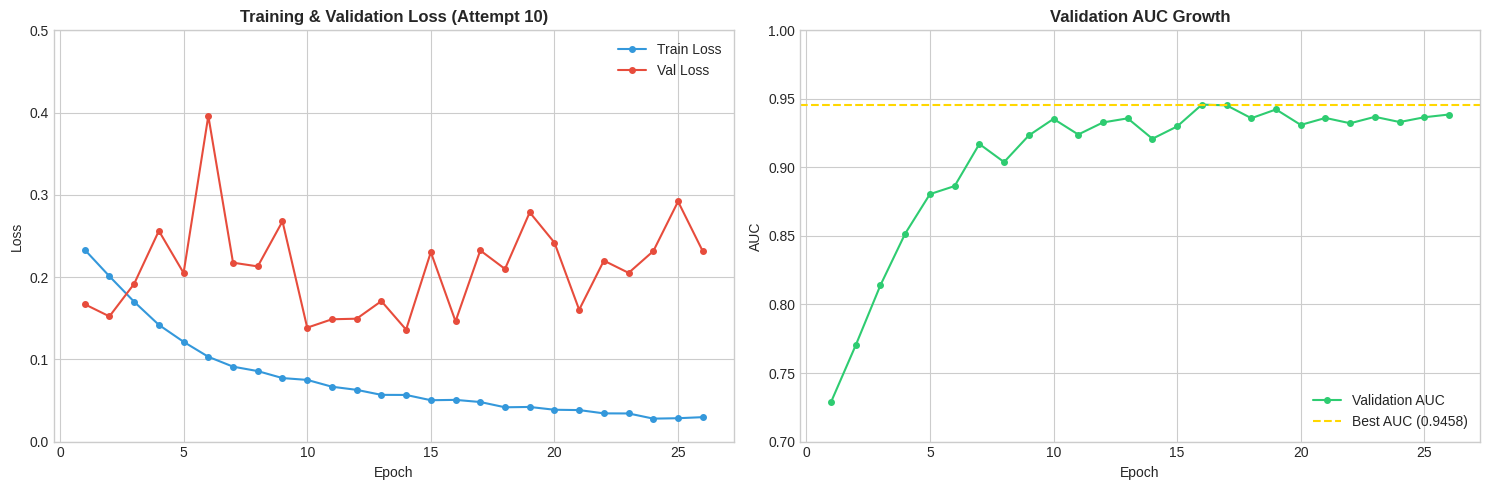

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reconstructed Data from Attempt 10 Logs
epochs = list(range(1, 27))
tr_loss = [0.2333, 0.2010, 0.1700, 0.1419, 0.1213, 0.1031, 0.0911, 0.0857, 0.0772, 0.0750, 
           0.0667, 0.0629, 0.0568, 0.0567, 0.0503, 0.0507, 0.0481, 0.0417, 0.0421, 0.0387, 
           0.0383, 0.0343, 0.0342, 0.0279, 0.0284, 0.0297]
vl_loss = [0.1670, 0.1522, 0.1918, 0.2562, 0.2050, 0.3960, 0.2175, 0.2130, 0.2678, 0.1385, 
           0.1487, 0.1494, 0.1708, 0.1361, 0.2303, 0.1462, 0.2324, 0.2099, 0.2787, 0.2419, 
           0.1603, 0.2200, 0.2051, 0.2316, 0.2919, 0.2314]
vl_auc  = [0.7288, 0.7703, 0.8141, 0.8517, 0.8805, 0.8864, 0.9171, 0.9039, 0.9233, 0.9354, 
           0.9240, 0.9328, 0.9358, 0.9209, 0.9299, 0.9458, 0.9453, 0.9359, 0.9423, 0.9310, 
           0.9361, 0.9322, 0.9369, 0.9331, 0.9366, 0.9386]

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Loss Curve
ax1.plot(epochs, tr_loss, 'o-', color='#3498db', label='Train Loss', markersize=4)
ax1.plot(epochs, vl_loss, 'o-', color='#e74c3c', label='Val Loss', markersize=4)
ax1.set_title('Training & Validation Loss (Attempt 10)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_ylim(0, 0.5)

# Plot 2: AUC Curve
ax2.plot(epochs, vl_auc, 'o-', color='#2ecc71', label='Validation AUC', markersize=4)
ax2.axhline(y=0.9458, color='gold', linestyle='--', label='Best AUC (0.9458)')
ax2.set_title('Validation AUC Growth', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.legend(loc='lower right')
ax2.set_ylim(0.7, 1.0)

plt.tight_layout()
plt.show()


---
## 🎬 Section 13 — Single-Video Inference

In [23]:
def predict_from_pt(pt_path, model, img_size=224, num_frames=8, thr=0.5):
    """Run inference on a single pre-extracted .pt file."""
    model.eval()
    data   = torch.load(pt_path, map_location='cpu', weights_only=False)
    frames = data['frames'].numpy()  # uint8 [T, H, W, 3]

    MEAN = np.array([0.485, 0.456, 0.406], np.float32)
    STD  = np.array([0.229, 0.224, 0.225], np.float32)
    x = frames.astype(np.float32) / 255.0
    x = (x - MEAN) / STD
    x = np.transpose(x, (0, 3, 1, 2))
    x = torch.tensor(x).unsqueeze(0).to(device)
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
        prob_fake = torch.sigmoid(model(x)).item()
    verdict = '🔴 FAKE' if prob_fake >= thr else '🟢 REAL'
    return {'pt_path': str(pt_path), 'prob_fake': round(prob_fake, 4),
            'prediction': verdict, 'threshold': round(thr, 2)}

# Demo on first test video
example_path = test_df.iloc[0]['pt_path']
actual = '🔴 FAKE' if test_df.iloc[0]['label'] == 1 else '🟢 REAL'
result = predict_from_pt(example_path, model, cfg.img_size, cfg.num_frames, best_thr)

print('─'*55)
print('  🎬 Single Video Inference')
print('─'*55)
print(f'  File      : {Path(example_path).name}')
print(f'  Actual    : {actual}')
print(f'  Predicted : {result["prediction"]}')
print(f'  Fake prob : {result["prob_fake"]:.4f}')
correct = (result['prob_fake'] >= best_thr) == (test_df.iloc[0]['label'] == 1)
print(f'  Correct?  : {"✅ Yes" if correct else "❌ No"}')
print('─'*55)

───────────────────────────────────────────────────────
  🎬 Single Video Inference
───────────────────────────────────────────────────────
  File      : celebdf_0_00015.pt
  Actual    : 🟢 REAL
  Predicted : 🟢 REAL
  Fake prob : 0.0359
  Correct?  : ✅ Yes
───────────────────────────────────────────────────────


Opening video: /kaggle/input/datasets/nightfury22344/video-test-real/YTDown.com_YouTube_Deepfake-Example-Presented-by-Senator-Ri_Media_iqji2dEX7No_002_720p.mp4 (4600 frames)

═══════════════════════════════════════════════════════
  🎬  INTERNET VIDEO INFERENCE RESULTS
═══════════════════════════════════════════════════════
  Verdict     : 🟢 REAL
  Probability : 0.0916
  Confidence  : 90.84%
═══════════════════════════════════════════════════════


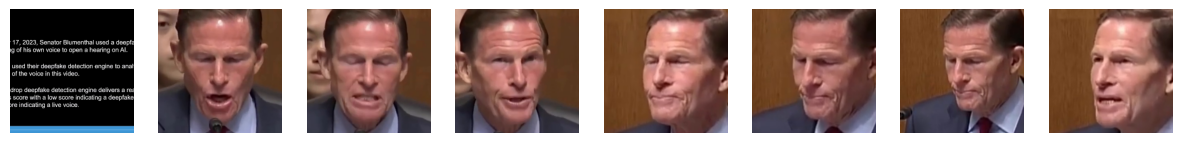

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

# ── 1. CONFIGURATION ─────────────────────────────────────────────────────────
VIDEO_PATH = "/kaggle/input/datasets/nightfury22344/video-test-real/YTDown.com_YouTube_Deepfake-Example-Presented-by-Senator-Ri_Media_iqji2dEX7No_002_720p.mp4" # ← Ensure file extension is included!
BEST_MODEL_PATH = "/kaggle/working/best_triple_stream_v10.pth"

# ── 2. INITIALIZE OPENCV FACE DETECTOR ───────────────────────────────────────
# This uses the built-in Haar Cascade detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def get_face_crop_cv2(frame):
    """Detects and crops the largest face using OpenCV Haar Cascades."""
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    
    if len(faces) == 0:
        # Fallback: Just crop the center if no face found
        H, W = frame.shape[:2]
        size = min(H, W)
        x1, y1 = (W - size) // 2, (H - size) // 2
        face = frame[y1:y1+size, x1:x1+size]
        return cv2.resize(face, (224, 224))

    # Pick largest face
    (x, y, w, h) = max(faces, key=lambda f: f[2] * f[3])
    
    # Add 20% padding
    H, W = frame.shape[:2]
    pad_w, pad_h = int(w * 0.2), int(h * 0.2)
    x1, y1 = max(0, x - pad_w), max(0, y - pad_h)
    x2, y2 = min(W, x + w + pad_w), min(H, y + h + pad_h)
    
    face = frame[y1:y2, x1:x2]
    return cv2.resize(face, (224, 224))

# ── 3. EXTRACT 8 FRAMES ──────────────────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

if total_frames <= 0:
    print(f"❌ Error: Could not read video. Check if the path is correct and has the extension (e.g. .mp4)!")
else:
    print(f"Opening video: {VIDEO_PATH} ({total_frames} frames)")
    frame_indices = np.linspace(0, total_frames - 1, cfg.num_frames, dtype=int)

    extracted_faces = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret: break
        face_crop = get_face_crop_cv2(frame)
        extracted_faces.append(cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB))
    cap.release()

    # ── 4. PREPROCESS & PREDICT ──────────────────────────────────────────────────
    MEAN = np.array([0.485, 0.456, 0.406], np.float32)
    STD  = np.array([0.229, 0.224, 0.225], np.float32)

    faces_arr = np.array(extracted_faces).astype(np.float32) / 255.0
    faces_arr = (faces_arr - MEAN) / STD
    faces_arr = np.transpose(faces_arr, (0, 3, 1, 2))

    input_tensor = torch.tensor(faces_arr).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        prob_fake = torch.sigmoid(logits).item()

    # ── 5. OUTPUT VERDICT ────────────────────────────────────────────────────────
    verdict = "🔴 FAKE" if prob_fake >= best_thr else "🟢 REAL"
    confidence = prob_fake if prob_fake >= best_thr else (1 - prob_fake)

    print("\n" + "═"*55)
    print("  🎬  INTERNET VIDEO INFERENCE RESULTS")
    print("═"*55)
    print(f"  Verdict     : {verdict}")
    print(f"  Probability : {prob_fake:.4f}")
    print(f"  Confidence  : {confidence*100:.2f}%")
    print("═"*55)

    # Show a preview
    plt.figure(figsize=(15, 3))
    for i, img in enumerate(extracted_faces):
        plt.subplot(1, 8, i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.show()


---
## 📝 Summary of Expected Outcomes

### Why Attempt 10 should fix the overfitting from Attempt 9:

1. **Full dataset (12,967 videos)** — More training data is the #1 defense against overfitting.
   Attempt 9 capped at ~10,500; Attempt 10 uses everything.

2. **Stochastic Depth (DropPath=0.2)** — Randomly drops entire ViT layers during training,
   preventing any single layer from becoming a "memorization bottleneck."

3. **Lower Learning Rate (3e-5)** — Prevents the aggressive weight updates that caused
   Attempt 9's VlLoss to spike after Epoch 4.

4. **Stronger Weight Decay (0.1)** — Keeps weights small and generalizable, penalizing
   the complex weight configurations that enable memorization.

5. **Label Smoothing (0.05)** — Targets become 0.025/0.975 instead of 0.0/1.0,
   preventing the model from becoming over-confident on easy examples.

6. **Enhanced Augmentations** — RandomResizedCrop + ShiftScaleRotate make it impossible
   for the model to memorize exact face positions or orientations.

7. **Save on Best AUC** — Attempt 9 saved on best VlLoss but AUC kept climbing even
   when VlLoss bounced. Now we save the model that actually performs best on our target metric.

### Target metrics:
| Metric | Attempt 8 | Attempt 9 (Peak) | Attempt 10 Target |
|---|---|---|---|
| Val AUC | 0.5457 | 0.9159 | >0.92 (sustained) |
| Val Accuracy | 0.7847 | 0.8951 | >0.90 |
| Test AUC | ~0.55 | ~0.90 | >0.90 |

### If results are below target, next steps:
1. Try `EMA` (Exponential Moving Average) of weights for smoother convergence
2. Add `Mixup` or `CutMix` at the video level
3. Freeze ViT backbone for first 3 epochs, then unfreeze
4. Try `vit_base_patch16_224` if VRAM permits